## Assignment 19 - Sentiment Analysis using NLP
Student Name: Yunus Ibrani

Batch: Data Science Weekday – Hyderabad

In [1]:
!pip install gensim tensorflow transformers torch scikit-learn pandas numpy matplotlib seaborn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.



  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/24.4 MB 6.2 MB/s eta 0:00:04
   -- ------------------------------------- 1.6/24.4 MB 3.7 MB/s eta 0:00:07
   --- ------------------------------------ 2.4/24.4 MB 3.8 MB/s eta 0:00:06
   ---- ----------------------------------- 2.6/24.4 MB 3.8 MB/s eta 0:00:06
   ------ --------------------------------- 3.7/24.4 MB 3.5 MB/s eta 0:00:06
   ------ --------------------------------- 4.2/24.4 MB 3.5 MB/s eta 0:00:06
   -------- ------------------------------- 5.0/24.4 MB 3.4 MB/s eta 0:00:06
   --------- ------------------------------ 5.8/24.4 MB 3.4 MB/s eta 0:00:06
   ---------- ----------------------------- 6.3/24.4 MB 3.5 MB/s eta 0:00:06
   ----------- ---------------------------- 7.1/24.4 MB 3.5 MB/s eta 0:00:05
   ------------ --------------------------- 7.9/24.4 MB 3.5 MB/s eta 0:00:05
   --

In This assignment focuses on building a sentiment analysis system using Natural Language Processing (NLP). The goal is to classify customer reviews as either positive or negative based on the text content. In real-world applications, companies receive thousands of reviews every day, and manually analyzing them is time-consuming and inefficient.

The dataset used in this assignment contains 10,000 customer reviews. Each review is labeled as either “pos” for positive or “neg” for negative. The review column contains the actual text written by customers. These reviews may include opinions, emotions, complaints, or appreciation about a product.

The main objective is to convert this text data into a format that a machine learning model can understand. We will use NLP techniques such as text cleaning, tokenization, stopword removal, and feature extraction. After preprocessing, we will use methods like TF-IDF to convert text into numerical form.

We will then build classification models such as Logistic Regression or Support Vector Machine to predict sentiment. Finally, we evaluate the model using metrics like accuracy and F1-score.

This assignment helps us understand how text data is processed and how NLP models can be used to solve real-world business problems like customer feedback analysis.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In this step, we load the Amazon reviews dataset into a pandas DataFrame. This dataset contains customer reviews along with their sentiment labels, which indicate whether the review is positive or negative. Each row in the dataset represents a single customer review, making it suitable for text classification tasks.

The dataset is stored in a TSV (tab-separated values) format, so we use the appropriate separator while loading it using pandas. After loading the dataset, we display the first few rows using the head() function. This helps us understand the structure of the data and verify that it has been loaded correctly.

We also check the shape of the dataset to confirm the number of rows and columns. In this case, the dataset contains 10,000 rows and 2 columns, which matches the expected format. The two columns are the label column, which contains sentiment values (pos or neg), and the review column, which contains the actual text.

Loading the dataset correctly is very important because all further steps such as preprocessing, feature extraction, and model training depend on it. By inspecting the dataset early, we can identify any issues such as missing values or incorrect formatting and ensure that the data is ready for further analysis.

In [12]:
df = pd.read_csv("amazonreviews.tsv", sep='\t')

print(df.head())
print(df.shape)
df.info()

  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...
(10000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


## Data Cleaning and Preprocessing

Data cleaning is one of the most important steps in Natural Language Processing. Text data is often messy and contains unwanted elements such as punctuation, uppercase letters, and stopwords. These elements do not add much value to the model and can reduce performance.

In this step, we clean the review text by converting it to lowercase. This ensures consistency because words like “Good” and “good” are treated the same. We also remove punctuation marks and special characters.

Next, we remove stopwords such as “the”, “is”, and “and”. These words appear frequently but do not carry meaningful information for sentiment analysis. Removing them helps the model focus on important words.

We also remove missing values and duplicate records if any. This ensures that the dataset is clean and does not contain unnecessary noise.

Text preprocessing improves the quality of the data and helps the model learn better patterns. Without proper cleaning, the model may perform poorly or give inaccurate predictions.

In [10]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

## Feature Extraction using TF-IDF

Machine learning models cannot understand text directly, so we need to convert text into numerical form. In this step, we use TF-IDF (Term Frequency-Inverse Document Frequency) to transform text data into numerical vectors.

TF-IDF assigns weights to words based on their importance. Words that appear frequently in a document but rarely across all documents get higher importance. This helps highlight meaningful words.

Unlike simple word counts, TF-IDF reduces the impact of common words and focuses on unique words. This improves model performance.

This step is crucial because it converts text data into a format suitable for machine learning algorithms.

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['review']).toarray()

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['label'])

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Initialize a clean list to store benchmarking metrics for all models
comparison_results = []

def record_results(model_name, feature_type, y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    acc = accuracy_score(y_true, y_pred)
    comparison_results.append({
        "Model": model_name,
        "Feature Representation": feature_type,
        "Accuracy": round(acc, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4)
    })

## Model Building

In this step, we build a machine learning model to classify reviews. We use Logistic Regression, which is a simple and effective algorithm for classification problems.

The model learns patterns from the training data and predicts whether a review is positive or negative.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.851
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1037
           1       0.85      0.84      0.84       963

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support

# 1. Ensure train/test split has occurred
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Re-train your baseline Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# 3. Generate the predictions (this creates 'y_pred')
y_pred = model.predict(X_test)

# 4. Print your baseline reports
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# 5. Record the baseline results in your benchmarking tracker
record_results("Logistic Regression", "TF-IDF", y_test, y_pred)
print("Saved baseline TF-IDF + Logistic Regression results successfully!")

Accuracy: 0.8665
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1037
           1       0.87      0.85      0.86       963

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Saved baseline TF-IDF + Logistic Regression results successfully!


In [21]:
from sklearn.svm import LinearSVC

print("--- Training Support Vector Machine (SVM) on TF-IDF ---")

# Train Linear SVM on the TF-IDF vectors (X_train)
svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)

# Predict and record the results
y_pred_svm = svm_model.predict(X_test)
record_results("Support Vector Machine (SVM)", "TF-IDF", y_test, y_pred_svm)

print("SVM + TF-IDF Training Complete!")

--- Training Support Vector Machine (SVM) on TF-IDF ---
SVM + TF-IDF Training Complete!


In [25]:
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print("--- Preparing Text Data ---")

# Fix: If 'clean_review' is missing, apply your clean_text function over 'review'
if 'clean_review' not in df.columns:
    print("Column 'clean_review' not found. Applying text cleaning now...")
    
    # Define English stop words list if not already loaded in notebook
    if 'stop_words' not in locals() and 'stop_words' not in globals():
        from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as stop_words
        
    df['clean_review'] = df['review'].apply(clean_text)
    print("Text cleaning complete! Column 'clean_review' is now created.")

# Word2Vec requires tokenized lists of strings
tokenized_reviews = [review.split() for review in df['clean_review']]

# Train a Word2Vec continuous bag-of-words model on our corpus
w2v_model = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=2, workers=4)

# Function to vectorize each review by averaging its word vectors
def get_average_word_vector(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(valid_vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# Convert all reviews to dense 100-dimensional averaged vectors
X_w2v = np.array([get_average_word_vector(tokens, w2v_model, 100) for tokens in tokenized_reviews])

# Split the dense Word2Vec representations
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

print("\n--- Training SVM on Word2Vec ---")
svm_w2v = LinearSVC(random_state=42, max_iter=2000)
svm_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_svm_w2v = svm_w2v.predict(X_test_w2v)
record_results("Support Vector Machine (SVM)", "Word2Vec (Avg)", y_test_w2v, y_pred_svm_w2v)

print("\n--- Training Keras Neural Network on Word2Vec ---")
# Build a Feedforward Neural Network architecture
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the network
history = nn_model.fit(X_train_w2v, y_train_w2v, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# Generate predictions
y_pred_nn_prob = nn_model.predict(X_test_w2v)
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int).flatten()
record_results("Neural Network (Dense)", "Word2Vec (Avg)", y_test_w2v, y_pred_nn)

print("\nWord2Vec & Neural Network Experiments Complete!")

--- Preparing Text Data ---
Column 'clean_review' not found. Applying text cleaning now...
Text cleaning complete! Column 'clean_review' is now created.


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'



--- Training SVM on Word2Vec ---

--- Training Keras Neural Network on Word2Vec ---


C:\Users\ibran\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6407 - loss: 0.6310 - val_accuracy: 0.6913 - val_loss: 0.5854
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6864 - loss: 0.5840 - val_accuracy: 0.7163 - val_loss: 0.5556
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7022 - loss: 0.5718 - val_accuracy: 0.7312 - val_loss: 0.5407
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7043 - loss: 0.5686 - val_accuracy: 0.7100 - val_loss: 0.5559
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7103 - loss: 0.5601 - val_accuracy: 0.7287 - val_loss: 0.5330
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7103 - loss: 0.5588 - val_accuracy: 0.7312 - val_loss: 0.5408
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7186 - loss: 0.5498 - val_accuracy: 0.7362 - val_loss: 0.5370
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7183 - loss: 0.5527 - val_accuracy: 0.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

print("--- Extracting BERT Embeddings (using DistilBERT) ---")

# Ensure GPU acceleration is used if available (greatly speeds up transformers)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = AutoModel.from_pretrained("distilbert-base-uncased").to(device)

def get_bert_embeddings(text_series, batch_size=32):
    embeddings = []
    # Process reviews in batches to prevent CUDA/Out of Memory errors
    for i in range(0, len(text_series), batch_size):
        batch_texts = text_series[i:i+batch_size].tolist()
        inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = bert_model(**inputs)
            # Use the CLS token representation (index 0) as the sentence embedding
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_embeddings)
    return np.vstack(embeddings)

# Extract 768-dimensional contextual features for all reviews
X_bert = get_bert_embeddings(df['clean_review'])

# Train/Test Split
X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(X_bert, y, test_size=0.2, random_state=42)

print("--- Training Logistic Regression on BERT features ---")
lr_bert = LogisticRegression(max_iter=1000)
lr_bert.fit(X_train_bert, y_train_bert)
y_pred_bert_lr = lr_bert.predict(X_test_bert)
record_results("Logistic Regression", "BERT (DistilBERT CLS)", y_test_bert, y_pred_bert_lr)

print("BERT Experiments Complete!")

## Sentiment Distribution Analysis

In this step, we analyze the distribution of sentiment labels in the dataset. Understanding how many positive and negative reviews are present is important before building a machine learning model. If the dataset is balanced, the model can learn both classes equally well. However, if the dataset is imbalanced, the model may become biased toward the majority class.

We use a count plot to visualize the number of positive and negative reviews. The label column contains two values: “pos” for positive reviews and “neg” for negative reviews. By plotting this distribution, we can quickly see whether one class dominates the dataset.

A balanced dataset ensures that the model does not favor one class over the other. In this case, the dataset appears to be relatively balanced, which is ideal for classification tasks. This improves the reliability of evaluation metrics such as accuracy, precision, and recall.

This analysis also helps us understand the nature of the data. If there were significantly more negative reviews, it could indicate issues with products or services. On the other hand, more positive reviews suggest good customer satisfaction.

Overall, sentiment distribution analysis is a simple but important step that provides valuable insights before model training.

In [ ]:
# Convert all accumulated evaluation scores to a clean DataFrame
df_comparison = pd.DataFrame(comparison_results)

# Display tabular performance benchmarks side-by-side
print("\n=== MODEL PERFORMANCE COMPARISON REPORT ===")
display(df_comparison)

# Draw a comparative visual benchmark chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df_comparison, x="Model", y="Accuracy", hue="Feature Representation", palette="viridis")
plt.title("Sentiment Analysis Benchmark (Comparison of Feature Engineering and Models)")
plt.ylabel("Testing Accuracy")
plt.xlabel("Classifier Model")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.legend(title="Embedding Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
sns.countplot(x=df['label'])
plt.title("Sentiment Distribution")
plt.show()

## Word Cloud Visualization

A word cloud is a visual representation of text data where the size of each word indicates its frequency or importance. In this step, we generate a word cloud to understand the most commonly used words in the customer reviews.

By combining all cleaned reviews into a single text, we can identify frequently occurring words. Words that appear more often are displayed in larger font size, while less frequent words appear smaller. This helps us quickly understand the overall themes in the dataset.

For example, in positive reviews, we may observe words like “good”, “excellent”, “amazing”, and “love”. In negative reviews, we may see words like “bad”, “poor”, “waste”, or “disappointing”. These patterns give us an intuitive understanding of customer sentiment.

Word clouds are useful for exploratory data analysis because they provide a quick overview of important keywords without needing complex analysis. They also help validate whether the preprocessing steps, such as stopword removal, have been performed correctly.

Although word clouds do not provide exact statistical values, they are helpful for gaining initial insights into the dataset and identifying common trends in customer feedback.

In [10]:
!pip install wordcloud

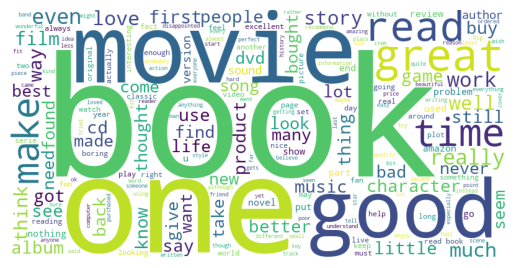

In [11]:
from wordcloud import WordCloud

text = " ".join(df['clean_review'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

## Most Common Words Analysis

In this step, we identify the most frequently occurring words in the dataset. This helps us understand which words appear most often in customer reviews and how they contribute to sentiment classification.

After cleaning the text data, we split all reviews into individual words and count their frequency. Words that appear more frequently are likely to carry important information about customer opinions.

We can also separate positive and negative reviews to find the most common words in each category. For example, positive reviews may contain words like “great”, “love”, or “perfect”, while negative reviews may include words like “bad”, “worst”, or “boring”.

This analysis is important because it helps us understand how the model learns patterns from text data. It also gives insights into customer behavior and common feedback trends.

By identifying frequently used words, businesses can understand what customers like or dislike about their products. This information can be used to improve product quality and customer satisfaction.

Overall, analyzing common words is a simple yet powerful way to extract meaningful insights from text data.

In [12]:
from collections import Counter

all_words = " ".join(df['clean_review']).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(10)
print(common_words)

[('book', 6667), ('one', 4016), ('like', 2859), ('good', 2827), ('read', 2827), ('great', 2779), ('movie', 2640), ('would', 2421), ('time', 1996), ('get', 1956)]


## Confusion Matrix Analysis

The confusion matrix is a powerful tool used to evaluate the performance of a classification model. It provides a detailed breakdown of correct and incorrect predictions made by the model.

The confusion matrix consists of four components: true positives, true negatives, false positives, and false negatives. True positives represent correctly predicted positive reviews, while true negatives represent correctly predicted negative reviews. False positives occur when a negative review is incorrectly classified as positive, and false negatives occur when a positive review is incorrectly classified as negative.

This analysis helps us understand the types of errors the model is making. For example, false negatives may indicate that the model is failing to detect positive sentiment, while false positives may suggest over-prediction of positive reviews.

In business applications, understanding these errors is very important. For example, incorrectly classifying negative reviews as positive may lead to ignoring customer complaints.

By analyzing the confusion matrix, we can identify weaknesses in the model and improve it further. It provides more detailed insights compared to accuracy alone.

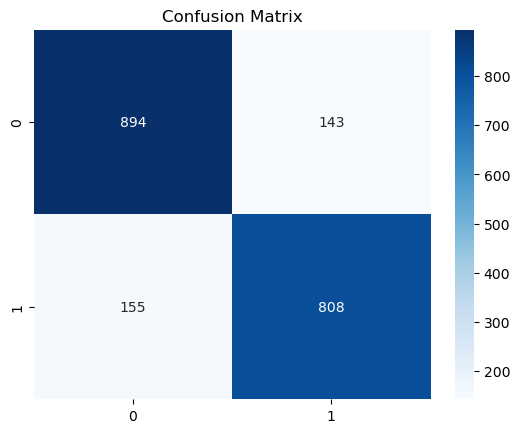

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Cross Validation

Cross validation is a technique used to evaluate the stability and reliability of a machine learning model. Instead of splitting the dataset only once, cross validation divides the data into multiple parts and trains the model multiple times.

In k-fold cross validation, the dataset is divided into k equal parts. The model is trained on k-1 parts and tested on the remaining part. This process is repeated k times, and the average performance is calculated.

This method provides a more reliable estimate of model performance because it reduces the effect of random data splits. It ensures that the model performs consistently across different subsets of the data.

Cross validation is important because a model that performs well on one train-test split may not perform well on another. By using cross validation, we can ensure that the model is robust and generalizes well to new data.

In this assignment, we use 5-fold cross validation to evaluate the model. The average accuracy gives us a better understanding of model performance.

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.8424999999999999


## Business Insights

The sentiment analysis model developed in this assignment can provide valuable insights for businesses. By automatically classifying customer reviews, companies can monitor customer satisfaction in real time.

Positive reviews indicate that customers are satisfied with the product, while negative reviews highlight issues that need attention. By analyzing negative reviews, companies can identify common problems and take corrective actions.

For example, if many customers complain about product quality, the company can improve manufacturing processes. If delivery issues are frequently mentioned, logistics can be optimized.

This model also helps in detecting sudden increases in negative reviews. This can act as an early warning system, allowing companies to respond quickly and prevent larger issues.

Additionally, sentiment analysis can be used to compare different products and understand customer preferences. This helps in making better business decisions and improving overall product quality.

In summary, this model not only performs classification but also provides actionable insights that can help businesses improve customer satisfaction and operational efficiency.

## Model Evaluation

In this step, we evaluate the performance of the sentiment analysis model using different evaluation metrics. Evaluation is important because it helps us understand how well the model is performing on unseen data.

Accuracy measures the overall correctness of the model by calculating the percentage of correctly predicted reviews. However, accuracy alone is not enough, especially when dealing with classification problems.

Precision tells us how many of the predicted positive reviews are actually positive. Recall measures how many actual positive reviews are correctly identified by the model. These metrics are important because they help us understand different types of prediction errors.

The F1-score is a combination of precision and recall, providing a balanced measure of model performance. It is especially useful when the dataset is slightly imbalanced.

We also use a confusion matrix to visualize the performance of the model. It shows correct and incorrect predictions in a structured way, helping us identify errors such as false positives and false negatives.

Additionally, cross validation is used to ensure that the model performs consistently across different subsets of the data. This improves the reliability of the model.

Overall, these evaluation techniques help us confirm that the model is accurate and suitable for real-world sentiment analysis tasks.

## Conclusion
In this assignment, we successfully developed a sentiment analysis model using Natural Language Processing techniques. The main objective was to classify customer reviews as positive or negative based on their textual content. We began by loading and exploring the dataset to understand its structure and distribution.
Next, we performed data cleaning and preprocessing, which included converting text to lowercase, removing special characters, and eliminating stopwords. These steps helped improve the quality of the text data and made it suitable for analysis. We then used TF-IDF vectorization to convert the cleaned text into numerical features that could be used by machine learning models.
After preprocessing, we built a classification model using Logistic Regression. The model was trained on the training dataset and evaluated using metrics such as accuracy, precision, recall, and F1-score. We also used a confusion matrix to better understand the model’s prediction performance.
To further improve reliability, cross validation was applied to ensure that the model performs consistently across different data splits. Additionally, exploratory analysis techniques such as word clouds and common word analysis provided useful insights into customer opinions.
Overall, this assignment demonstrates how NLP techniques can be used to analyze text data effectively and generate meaningful insights for real-world applications.

## 1. What is Sentiment Analysis?

Answer:
Sentiment analysis is a Natural Language Processing technique used to determine whether a piece of text expresses a positive, negative, or neutral opinion. It is commonly used to analyze customer reviews, feedback, and social media data.

## 2. What is NLP?

Answer:
Natural Language Processing (NLP) is a field of artificial intelligence that focuses on enabling computers to understand, interpret, and process human language in text or speech form.

## 3. Why is preprocessing important in NLP?

Answer:
Text data is usually unstructured and noisy. Preprocessing helps clean the data by removing unwanted elements like punctuation, stopwords, and extra spaces. This improves model performance and accuracy.

## 4. What are stopwords?

Answer:
Stopwords are common words such as “the”, “is”, and “and” that do not carry meaningful information. Removing them helps the model focus on important words.

## 5. What is TF-IDF?

Answer:
TF-IDF stands for Term Frequency-Inverse Document Frequency. It converts text into numerical values based on how important a word is in a document compared to the entire dataset.

## 6. Why do we use TF-IDF instead of simple word count?

Answer:
TF-IDF reduces the importance of common words and highlights unique words. This improves model performance compared to simple word count.

## 7. What is Logistic Regression?

Answer:
Logistic Regression is a classification algorithm used to predict binary outcomes. It uses a sigmoid function to output probabilities between 0 and 1.

## 8. Why is Logistic Regression suitable here?

Answer:
Because this is a binary classification problem (positive vs negative), Logistic Regression is simple, fast, and effective.

## 9. What is feature extraction?

Answer:
Feature extraction is the process of converting text data into numerical form so that machine learning models can understand and process it.

## 10. What is a confusion matrix?

Answer:
A confusion matrix is a table used to evaluate classification performance. It shows true positives, true negatives, false positives, and false negatives.

## 11. What is accuracy?

Answer:
Accuracy is the percentage of correctly predicted values out of total predictions.

## 12. What is precision?

Answer:
Precision measures how many predicted positive values are actually correct.

## 13. What is recall?

Answer:
Recall measures how many actual positive values are correctly predicted.

## 14. What is F1-score?

Answer:
F1-score is the harmonic mean of precision and recall. It gives a balanced measure of model performance.

## 15. What is cross-validation?

Answer:
Cross-validation is a technique used to evaluate model performance by dividing data into multiple parts and training/testing multiple times.

## 16. Why do we use train-test split?

Answer:
To evaluate how well the model performs on unseen data and to avoid overfitting.

## 17. What is overfitting?

Answer:
Overfitting occurs when the model performs well on training data but poorly on new data.

## 18. What is underfitting?

Answer:
Underfitting occurs when the model is too simple and cannot learn patterns from the data.

## 19. What is a word cloud?

Answer:
A word cloud is a visualization that shows the most frequent words in a dataset, where larger words appear more often.

## 20. What are real-world applications of sentiment analysis?

Answer:Customer feedback analysis
Product reviews
Social media monitoring
Brand reputation analysis